<a href="https://colab.research.google.com/github/Shivssv1012/Machine-learning-from-scratch/blob/main/transformations_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df=pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
#filling missing values in age with the overall mean
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_1815/3839043739.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [ ]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [ ]:
X_train,X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

/tmp/ipykernel_1815/2473566923.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


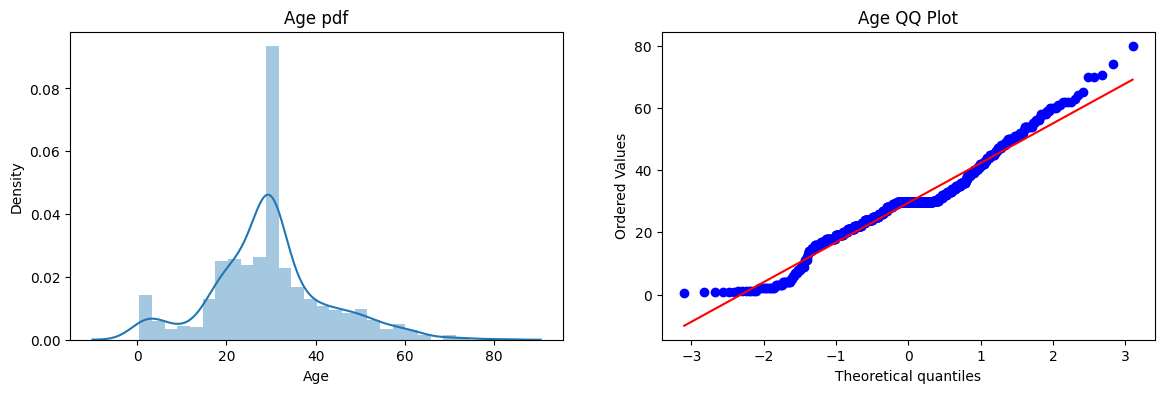

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm", plot=plt)
plt.title('Age QQ Plot')
plt.show()

/tmp/ipykernel_1815/662793424.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


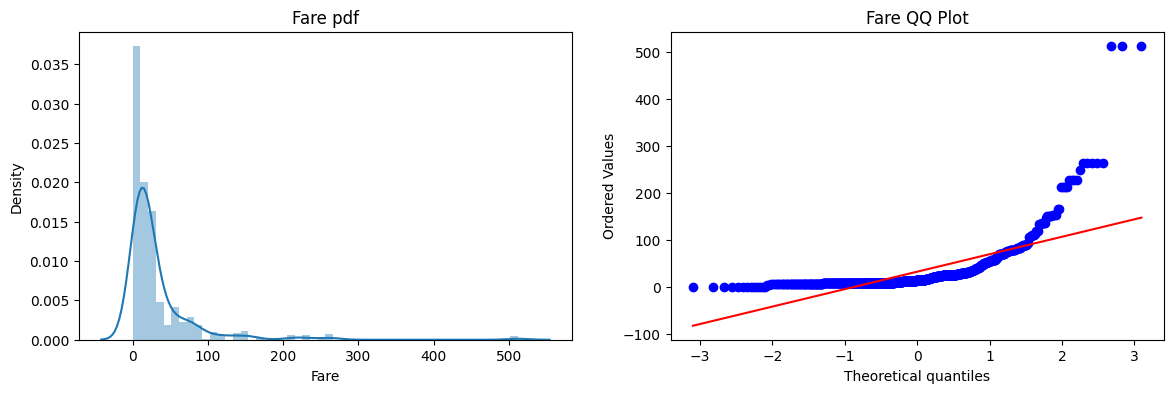

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()


In [ ]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [ ]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
y_pred=clf.predict(X_test)
y_pred2=clf2.predict(X_test)

print("Accuracy with LR: ", accuracy_score(y_test, y_pred))
print("Accuracy with DT: ", accuracy_score(y_test, y_pred2))

Accuracy with LR:  0.6480446927374302
Accuracy with DT:  0.659217877094972


Applying Transformation

In [ ]:
trf=FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [ ]:
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)

print("Accuracy with LR: ",accuracy_score(y_test,y_pred))
print("Accuracy with DT: ", accuracy_score(y_test,y_pred))

Accuracy with LR:  0.6815642458100558
Accuracy with DT:  0.6815642458100558


/tmp/ipykernel_1815/255527721.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed['Age'])


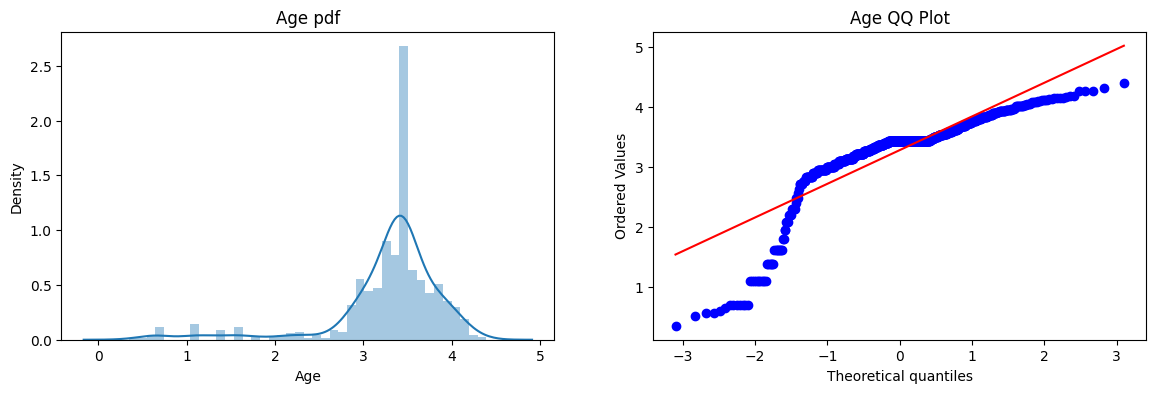

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train_transformed['Age'])
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist="norm", plot=plt)
plt.title('Age QQ Plot')
plt.show()

/tmp/ipykernel_1815/1705124416.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed['Fare'])


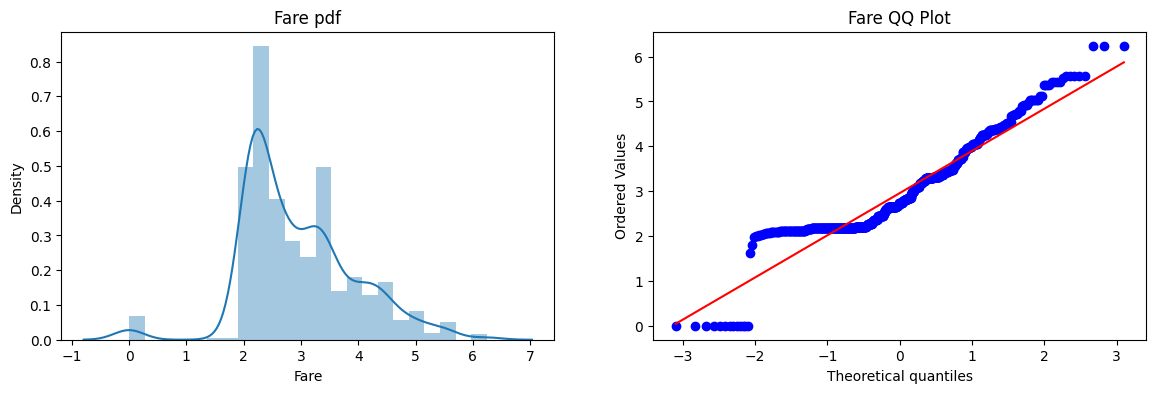

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train_transformed['Fare'])
plt.title('Fare pdf')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()


In [ ]:
#cross validation
X_transformed=trf.fit_transform(X)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("LR: ", np.mean(cross_val_score(clf,X_transformed,y,cv=10,scoring='accuracy')))
print("DT: ", np.mean(cross_val_score(clf2,X_transformed,y,cv=10,scoring='accuracy')))

LR:  0.678027465667915
DT:  0.6666916354556804


In [ ]:
#not applying transformation on Age
trf2=ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')
X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2=trf2.fit_transform(X_test)

In [ ]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2,y_train)
y_pred=clf.predict(X_test_transformed2)
y_pred2=clf2.predict(X_test_transformed2)

print("Accuracy with LR: ",accuracy_score(y_test,y_pred))
print("Accuracy with DT: ", accuracy_score(y_test,y_pred2))

Accuracy with LR:  0.6703910614525139
Accuracy with DT:  0.6759776536312849


In [ ]:
def apply_transform(transform):
  X=df.iloc[:,1:3]
  y=df.iloc[:,0]
  trf=ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')
  X_trans=trf.fit_transform(X)
  clf=LogisticRegression()
  print("Accuracy: ",np.mean(cross_val_score(clf,X_trans,y,cv=10, scoring='accuracy')))
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  stats.probplot(X['Fare'], dist='norm', plot=plt)
  plt.title('Fare before pdf')

  plt.subplot(122)
  stats.probplot(X['Fare'], dist='norm',plot=plt)
  plt.title('Fare after pdf')
  plt.show()


Accuracy:  0.61729088639201


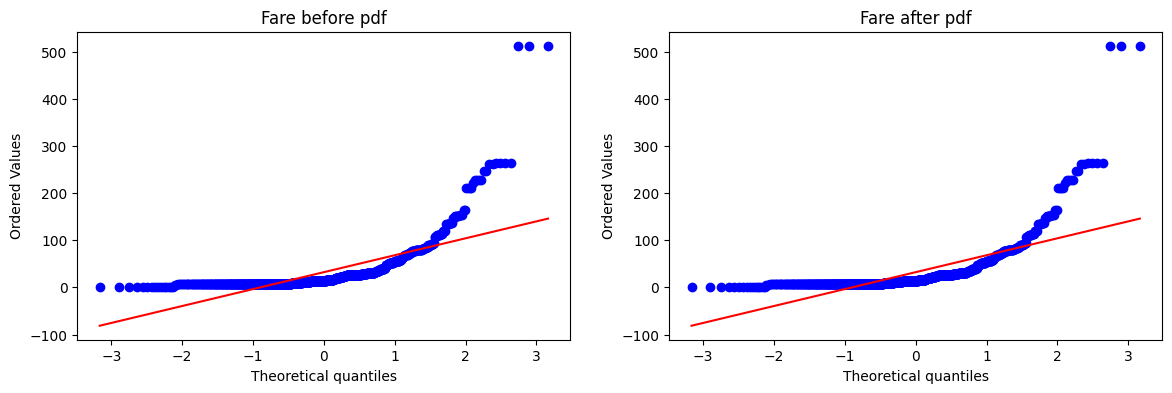

In [ ]:
 #apply_transform(lambda x:x) #without any transformation
 #apply_transform(lambda x: x**2) #square trans...
 #apply_transform(lambda x: x**1/2)
 #apply_transform(lambda x: x**3)
apply_transform(lambda x: 1/(x+0.00001))